# Intelligent Resume Screening and Job Role Prediction using NLP
## BITS WILP - Natural Language Processing Assignment 1

This notebook implements a comprehensive NLP pipeline for automated resume analysis and job role classification using state-of-the-art techniques including neural language models, word embeddings, POS tagging, HMM, and syntactic parsing.

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import os
import warnings
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

# Text processing and NLP libraries
import re
import string
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk
import spacy

# Word embedding libraries
from gensim.models import Word2Vec, FastText
from gensim.corpora import Dictionary

# Machine learning and neural network libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Input, concatenate, Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import networkx as nx

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('words', quiet=True)

# Load spaCy model
try:
    nlp = spacy.load('en_core_web_sm')
except Exception:
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

print("✓ All libraries loaded successfully")


✓ All libraries loaded successfully


## Section 1: Load and Explore Dataset
Loading the resume dataset from CSV and analyzing the distribution across different job categories.

In [16]:
# Load resume dataset from the workspace copy of the CSV file
base_dir = Path.cwd()
dataset_path = base_dir / 'Dataset' / 'Resume' / 'Resume.csv'

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset file not found: {dataset_path}")

# Read the CSV file with appropriate encoding
# Use Resume_str as the primary text column, but keep a compatible Resume alias
resume_text_col = 'Resume_str' if 'Resume_str' in pd.read_csv(dataset_path, encoding='latin-1').columns else 'Resume'

df_resumes = pd.read_csv(dataset_path, encoding='latin-1')
if 'Resume' not in df_resumes.columns:
    df_resumes['Resume'] = df_resumes[resume_text_col]

print(f"Dataset loaded successfully!")
print(f"Total resumes: {len(df_resumes)}")
print(f"Columns: {df_resumes.columns.tolist()}")
print(f"Using resume text column: {resume_text_col}")
print(f"\nFirst few rows:")
print(df_resumes.head())


Dataset loaded successfully!
Total resumes: 2484
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category', 'Resume']
Using resume text column: Resume_str

First few rows:
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  \
0  <div class="fontsize fontface vmargins hmargin...       HR   
1  <div class="fontsize fontface vmargins hmargin...       HR   
2  <div class="fontsize fontface vmargins hmargin...       HR   
3  <div class="fontsize fontface vmargins hmargin...       HR   
4  <div class="fontsize fontface vmargins hmargin...       HR   

                                          

In [4]:
# Display dataset statistics and information
print("Dataset Information:")
print(f"Total records: {len(df_resumes)}")
print(f"Columns: {df_resumes.columns.tolist()}")
print(f"\nData types:")
print(df_resumes.dtypes)
print(f"\nMissing values:")
print(df_resumes.isnull().sum())
print(f"\nBasic statistics:")
print(df_resumes.describe())

Dataset Information:
Total records: 2484
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category', 'Resume']

Data types:
ID             int64
Resume_str       str
Resume_html      str
Category         str
Resume           str
dtype: object

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
Resume         0
dtype: int64

Basic statistics:
                 ID
count  2.484000e+03
mean   3.182616e+07
std    2.145735e+07
min    3.547447e+06
25%    1.754430e+07
50%    2.521031e+07
75%    3.611444e+07
max    9.980612e+07



Job Category Distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Total unique categories: 24


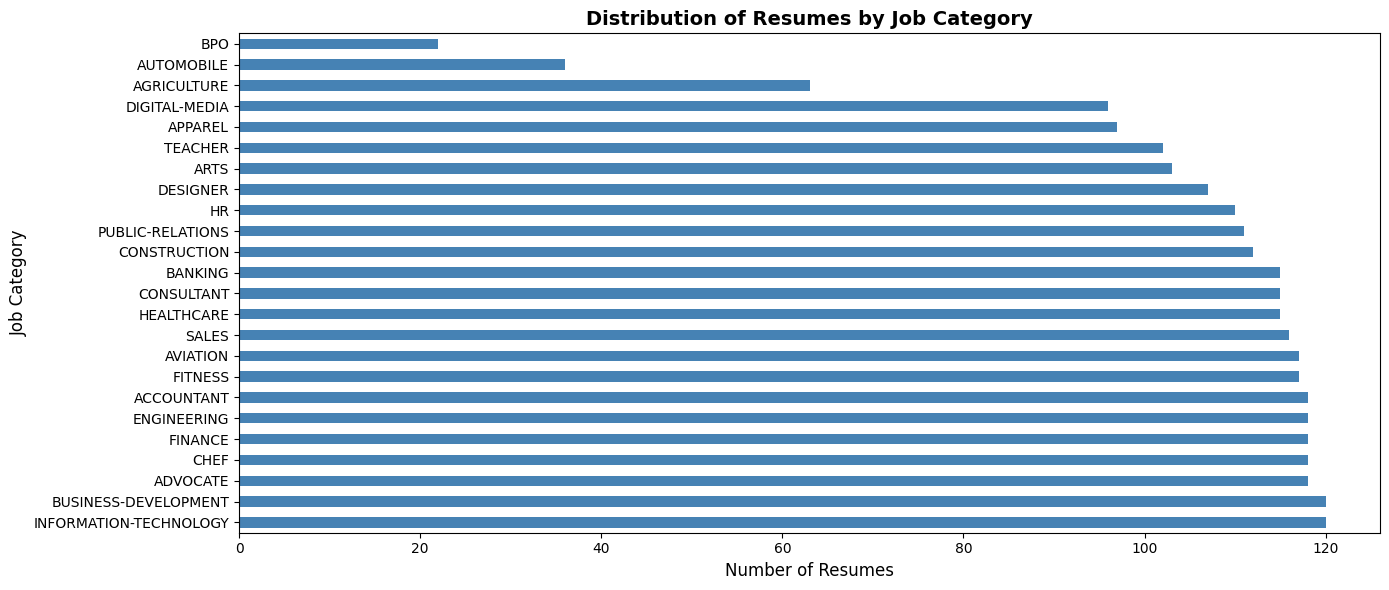


Sample resumes from different categories:

Category: HR
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-ta...

Category: DESIGNER
         DESIGNER       Summary     Designer with more than 15 years in product design, manufacturing, exhibit design and visual merchandising,  with comprehensive management and logistics experience who thrives in dynamically changing environments. Â            Highlights          Design processing expertise  Proficient in AutoCAD  Adobe Photoshop  Concept development  Product specifications  Color and material appli

In [5]:
# Analyze job category distribution
if 'Category' in df_resumes.columns:
    print("\nJob Category Distribution:")
    category_counts = df_resumes['Category'].value_counts()
    print(category_counts)
    print(f"\nTotal unique categories: {len(category_counts)}")
    
    # Visualize distribution
    plt.figure(figsize=(14, 6))
    category_counts.plot(kind='barh', color='steelblue')
    plt.title('Distribution of Resumes by Job Category', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Resumes', fontsize=12)
    plt.ylabel('Job Category', fontsize=12)
    plt.tight_layout()
    plt.show()
    
# Display sample resumes from different categories
print("\nSample resumes from different categories:")
if 'Category' in df_resumes.columns and 'Resume' in df_resumes.columns:
    for category in df_resumes['Category'].unique()[:3]:
        sample = df_resumes[df_resumes['Category'] == category]['Resume'].iloc[0]
        print(f"\n{'='*50}")
        print(f"Category: {category}")
        print(f"{'='*50}")
        print(sample[:500] + "..." if len(sample) > 500 else sample)

## Section 2: Data Preprocessing and Cleaning
Remove null values, handle special characters, and create a clean dataset for further processing.

In [6]:
# Function to clean resume text
def clean_text(text):
    '''
    Clean resume text by removing special characters, extra whitespace, and converting to lowercase
    '''
    if pd.isnull(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply cleaning to resume text
print("Cleaning resume text...")
df_resumes['cleaned_resume'] = df_resumes['Resume_str'].apply(clean_text)

# Remove duplicates
print(f"Rows before removing duplicates: {len(df_resumes)}")
df_resumes = df_resumes.drop_duplicates(subset=['cleaned_resume'], keep='first')
print(f"Rows after removing duplicates: {len(df_resumes)}")

# Remove rows with empty resumes
df_resumes = df_resumes[df_resumes['cleaned_resume'].str.len() > 20]
print(f"Rows after removing short resumes: {len(df_resumes)}")

# Reset index
df_resumes.reset_index(drop=True, inplace=True)

print(f"\nCleaned dataset shape: {df_resumes.shape}")
print(f"\nSample cleaned resume:")
print(df_resumes['cleaned_resume'].iloc[0][:300])

Cleaning resume text...
Rows before removing duplicates: 2484
Rows after removing duplicates: 2482
Rows after removing short resumes: 2481

Cleaned dataset shape: (2481, 6)

Sample cleaned resume:
hr administrator marketing associate hr administrator summary dedicated customer service manager with 15 years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service h


## Section 3: Text Normalization and Tokenization
Apply tokenization, remove stopwords, and apply lemmatization for text normalization.

In [7]:
# Initialize lemmatizer and get stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to tokenize and normalize text
def normalize_and_tokenize(text):
    '''
    Tokenize text into sentences and words, remove stopwords, and apply lemmatization
    '''
    # Tokenize into sentences
    sentences = sent_tokenize(text)
    
    normalized_tokens = []
    for sentence in sentences:
        # Tokenize into words
        tokens = word_tokenize(sentence)
        
        # Remove stopwords, punctuation, and apply lemmatization
        for token in tokens:
            if token.lower() not in stop_words and token.lower() not in string.punctuation:
                lemma = lemmatizer.lemmatize(token.lower())
                if len(lemma) > 2:  # Keep words with length > 2
                    normalized_tokens.append(lemma)
    
    return normalized_tokens

# Apply normalization to all resumes
print("Tokenizing and normalizing resumes...")
df_resumes['tokens'] = df_resumes['cleaned_resume'].apply(normalize_and_tokenize)

# Create a list of all tokens across the corpus (for embedding training)
all_tokens = [tokens for tokens in df_resumes['tokens']]

print(f"Sample tokens from first resume: {df_resumes['tokens'].iloc[0][:20]}")
print(f"Number of tokens in first resume: {len(df_resumes['tokens'].iloc[0])}")
print(f"\nTotal number of resumes tokenized: {len(all_tokens)}")

Tokenizing and normalizing resumes...
Sample tokens from first resume: ['administrator', 'marketing', 'associate', 'administrator', 'summary', 'dedicated', 'customer', 'service', 'manager', 'year', 'experience', 'hospitality', 'customer', 'service', 'management', 'respected', 'builder', 'leader', 'customer', 'focused']
Number of tokens in first resume: 507

Total number of resumes tokenized: 2481


## Section 4: Vector Embeddings (Word2Vec and GloVe)
Train Word2Vec models using Skip-gram and CBOW approaches, and generate document-level embeddings.

In [8]:
# Train Word2Vec models - Skip-gram and CBOW
print("Training Word2Vec models...")

# Skip-gram model
w2v_skipgram = Word2Vec(sentences=all_tokens, vector_size=100, window=5, min_count=2, workers=4, sg=1, epochs=5)
print(f"Skip-gram model trained: vocabulary size = {len(w2v_skipgram.wv)}")

# CBOW model
w2v_cbow = Word2Vec(sentences=all_tokens, vector_size=100, window=5, min_count=2, workers=4, sg=0, epochs=5)
print(f"CBOW model trained: vocabulary size = {len(w2v_cbow.wv)}")

# Function to create document embeddings by averaging word vectors
def get_document_embedding(tokens, model, embedding_dim=100):
    '''
    Generate document-level embedding by averaging word vectors from Word2Vec model
    '''
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    
    if len(vectors) == 0:
        return np.zeros(embedding_dim)
    
    return np.mean(vectors, axis=0)

# Generate embeddings using Skip-gram
print("\nGenerating document embeddings using Skip-gram...")
df_resumes['embedding_skipgram'] = df_resumes['tokens'].apply(lambda x: get_document_embedding(x, w2v_skipgram))

# Generate embeddings using CBOW
print("Generating document embeddings using CBOW...")
df_resumes['embedding_cbow'] = df_resumes['tokens'].apply(lambda x: get_document_embedding(x, w2v_cbow))

print(f"Embedding shape: {df_resumes['embedding_skipgram'].iloc[0].shape}")
print(f"Sample Skip-gram embedding (first 10 dims): {df_resumes['embedding_skipgram'].iloc[0][:10]}")

Training Word2Vec models...
Skip-gram model trained: vocabulary size = 20329
CBOW model trained: vocabulary size = 20329

Generating document embeddings using Skip-gram...
Generating document embeddings using CBOW...
Embedding shape: (100,)
Sample Skip-gram embedding (first 10 dims): [-0.13359028  0.17419846 -0.0767336   0.22052442  0.32303724 -0.21997909
  0.5984694   0.26622817  0.0794874   0.0812812 ]


In [9]:
# Train FastText model for better handling of out-of-vocabulary words
print("Training FastText model...")
fasttext_model = FastText(sentences=all_tokens, vector_size=100, window=5, min_count=2, workers=4, epochs=5)
print(f"FastText model trained: vocabulary size = {len(fasttext_model.wv)}")

# Generate FastText embeddings
print("Generating document embeddings using FastText...")
df_resumes['embedding_fasttext'] = df_resumes['tokens'].apply(lambda x: get_document_embedding(x, fasttext_model))

# Analyze word similarity using Skip-gram model
print("\n--- Word Similarity Analysis using Skip-gram ---")
try:
    similar_words = w2v_skipgram.wv.most_similar('python', topn=5)
    print(f"Words most similar to 'python': {similar_words}")
except:
    print("'python' not in vocabulary")

# Calculate cosine similarity between sample resumes
from sklearn.metrics.pairwise import cosine_similarity

sample_embeddings = np.array([df_resumes['embedding_skipgram'].iloc[i] for i in range(min(5, len(df_resumes)))])
similarity_matrix = cosine_similarity(sample_embeddings)

print(f"\nCosine Similarity Matrix (first 5 resumes):")
print(np.round(similarity_matrix, 3))

Training FastText model...
FastText model trained: vocabulary size = 20329
Generating document embeddings using FastText...

--- Word Similarity Analysis using Skip-gram ---
Words most similar to 'python': [('perl', 0.8755290508270264), ('postgresql', 0.8188295960426331), ('scripting', 0.8092615008354187), ('pspice', 0.8076832294464111), ('rational', 0.8026629686355591)]

Cosine Similarity Matrix (first 5 resumes):
[[1.    0.968 0.982 0.972 0.973]
 [0.968 1.    0.965 0.945 0.961]
 [0.982 0.965 1.    0.955 0.99 ]
 [0.972 0.945 0.955 1.    0.952]
 [0.973 0.961 0.99  0.952 1.   ]]


## Section 5: Neural Language Model Development
Build a neural language model using LSTM to predict contextual words in resumes.

In [10]:
# Prepare data for neural language model training
# Create sequences of tokens for next word prediction task
print("Preparing sequences for neural language model...")

# Create dictionary and corpus from tokens
dictionary = Dictionary(all_tokens)
print(f"Vocabulary size: {len(dictionary)}")

# Prepare training sequences (use sliding window approach)
max_sequence_length = 20
sequences = []
labels = []

for token_list in all_tokens:
    if len(token_list) > max_sequence_length:
        for i in range(len(token_list) - max_sequence_length):
            sequence = token_list[i:i+max_sequence_length]
            next_word = token_list[i+max_sequence_length]
            
            # Convert to word IDs
            seq_ids = [dictionary.token2id[word] for word in sequence if word in dictionary.token2id]
            if next_word in dictionary.token2id:
                sequences.append(seq_ids)
                labels.append(dictionary.token2id[next_word])

print(f"Total training sequences: {len(sequences)}")

# Pad sequences to uniform length
sequences_padded = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

# Convert labels to numpy array
labels = np.array(labels)

# Split into train and test
X_train_lm, X_test_lm, y_train_lm, y_test_lm = train_test_split(
    sequences_padded, labels, test_size=0.2, random_state=42
)

print(f"Training sequences shape: {X_train_lm.shape}")
print(f"Training labels shape: {y_train_lm.shape}")

Preparing sequences for neural language model...
Vocabulary size: 35397
Total training sequences: 1438523
Training sequences shape: (1150818, 20)
Training labels shape: (1150818,)


In [17]:
# Build a simpler neural language model first
print("Building a simpler Neural Language Model...")

nlm_model = Sequential([
    Embedding(input_dim=len(dictionary), output_dim=32, input_length=max_sequence_length),
    LSTM(64),
    Dense(len(dictionary), activation='softmax')
])

# Compile model
nlm_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Build the model explicitly so summary shows concrete shapes
nlm_model.build((None, max_sequence_length))

print("\nNeural Language Model Architecture:")
nlm_model.summary()

# Train the model
print("\nTraining Neural Language Model...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lm = nlm_model.fit(
    X_train_lm, y_train_lm,
    validation_data=(X_test_lm, y_test_lm),
    epochs=8,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = nlm_model.evaluate(X_test_lm, y_test_lm, verbose=0)
print(f"\nNeural Language Model Test Accuracy: {test_acc:.4f}")
print(f"Neural Language Model Test Loss: {test_loss:.4f}")


Building a simpler Neural Language Model...

Neural Language Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 20, 32)         │     1,132,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 35397)          │     2,300,805 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,458,341 (13.19 MB)

 Trainable params: 3,458,341 (13.19 MB)

 Non-trainable params: 0 (0.00 B)


Training Neural Language Model...
Epoch 1/8
17982/17982 ━━━━━━━━━━━━━━━━━━━━ 413s 23ms/step - accuracy: 0.0620 - loss: 7.1657 - val_accuracy: 0.0900 - val_loss: 6.6972
Epoch 2/8
17982/17982 ━━━━━━━━━━━━━━━━━━━━ 419s 23ms/step - accuracy: 0.1058 - loss: 6.4170 - val_accuracy: 0.1141 - val_loss: 6.3832
Epoch 3/8
17982/17982 ━━━━━━━━━━━━━━━━━━━━ 428s 24ms/step - accuracy: 0.1250 - loss: 6.1211 - val_accuracy: 0.1242 - val_loss: 6.2720
Epoch 4/8
17982/17982 ━━━━━━━━━━━━━━━━━━━━ 436s 24ms/step - accuracy: 0.1366 - loss: 5.9520 - val_accuracy: 0.1305 - val_loss: 6.2226
Epoch 5/8
17982/17982 ━━━━━━━━━━━━━━━━━━━━ 437s 24ms/step - accuracy: 0.1448 - loss: 5.8343 - val_accuracy: 0.1350 - val_loss: 6.2033
Epoch 6/8
17982/17982 ━━━━━━━━━━━━━━━━━━━━ 441s 25ms/step - accuracy: 0.1512 - loss: 5.7435 - val_accuracy: 0.1367 - val_loss: 6.1963
Epoch 7/8
17982/17982 ━━━━━━━━━━━━━━━━━━━━ 441s 25ms/step - accuracy: 0.1559 - loss: 5.6701 - val_accuracy: 0.1379 - val_loss: 6.1945
Epoch 8/8
17982/17982 ━━━━━

In [ ]:
# Visualize training history and calculate perplexity
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot training and validation loss
axes[0].plot(history_lm.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_lm.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Neural Language Model - Loss Convergence', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot training and validation accuracy
axes[1].plot(history_lm.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_lm.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Neural Language Model - Accuracy', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate perplexity
import math
perplexity = math.exp(test_loss)
print(f"\nPerplexity on test set: {perplexity:.4f}")
print(f"(Lower perplexity indicates better model performance)")

## Section 6: Part-of-Speech Tagging
Implement POS tagging using NLTK and spaCy to identify skills, qualifications, and action verbs.

In [ ]:
# POS Tagging using NLTK
print("Performing Part-of-Speech Tagging on resumes...")

def extract_pos_tags(text):
    '''
    Extract POS tags from cleaned text and return tagged tokens
    '''
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    return pos_tags

# Apply POS tagging to cleaned resumes
df_resumes['pos_tags'] = df_resumes['cleaned_resume'].apply(extract_pos_tags)

# Extract specific POS types that are relevant to resumes
def extract_action_verbs_and_nouns(pos_tags):
    '''
    Extract action verbs (VB*) and nouns (NN*) from POS tagged tokens
    '''
    action_verbs = []
    nouns = []
    
    for word, pos in pos_tags:
        if pos.startswith('VB'):  # All verb types (VB, VBP, VBZ, VBD, VBG)
            action_verbs.append(word)
        elif pos.startswith('NN'):  # All noun types (NN, NNS, NNP, NNPS)
            nouns.append(word)
    
    return list(set(action_verbs)), list(set(nouns))

# Extract action verbs and nouns
df_resumes[['action_verbs', 'nouns']] = df_resumes['pos_tags'].apply(
    lambda x: pd.Series(extract_action_verbs_and_nouns(x))
)

print(f"Sample POS tags from first resume:")
print(df_resumes['pos_tags'].iloc[0][:15])
print(f"\nAction verbs found: {df_resumes['action_verbs'].iloc[0][:10]}")
print(f"Nouns found: {df_resumes['nouns'].iloc[0][:10]}")

In [ ]:
# Analyze POS distribution across resumes
from collections import Counter

# Extract all POS tags from all resumes
all_pos_tags = []
for pos_list in df_resumes['pos_tags']:
    all_pos_tags.extend([pos for word, pos in pos_list])

# Count POS tag frequencies
pos_counts = Counter(all_pos_tags)

print("Top 15 Most Frequent POS Tags in Resumes:")
for pos, count in pos_counts.most_common(15):
    print(f"  {pos}: {count}")

# Visualize POS distribution
plt.figure(figsize=(12, 5))
top_pos = dict(pos_counts.most_common(10))
plt.bar(top_pos.keys(), top_pos.values(), color='skyblue', edgecolor='navy', alpha=0.7)
plt.xlabel('POS Tag', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Top 10 POS Tags in Resume Dataset', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze action verbs distribution
action_verbs_list = []
for verbs in df_resumes['action_verbs']:
    action_verbs_list.extend(verbs)

verb_counts = Counter(action_verbs_list)
print(f"\nTop 15 Action Verbs in Resumes:")
for verb, count in verb_counts.most_common(15):
    print(f"  {verb}: {count}")

## Section 7: Hidden Markov Model Implementation
Build HMM-based model for sequence tagging using Viterbi algorithm.

In [ ]:
# Hidden Markov Model for POS tagging
from collections import defaultdict

class HiddenMarkovModel:
    '''
    HMM for POS tagging using Viterbi algorithm for decoding
    '''
    def __init__(self):
        self.transition_probs = defaultdict(lambda: defaultdict(float))
        self.emission_probs = defaultdict(lambda: defaultdict(float))
        self.pos_tags = set()
        self.words = set()
        self.initial_probs = defaultdict(float)
        
    def train(self, tagged_sequences):
        '''
        Train HMM from POS-tagged sequences
        '''
        # Count transitions, emissions, and initial states
        transition_counts = defaultdict(lambda: defaultdict(int))
        emission_counts = defaultdict(lambda: defaultdict(int))
        initial_counts = defaultdict(int)
        pos_counts = defaultdict(int)
        
        for sequence in tagged_sequences:
            if len(sequence) > 0:
                # Initial state
                initial_counts[sequence[0][1]] += 1
                
                for i, (word, pos) in enumerate(sequence):
                    self.pos_tags.add(pos)
                    self.words.add(word)
                    emission_counts[pos][word] += 1
                    pos_counts[pos] += 1
                    
                    # Transition
                    if i < len(sequence) - 1:
                        next_pos = sequence[i + 1][1]
                        transition_counts[pos][next_pos] += 1
        
        # Convert counts to probabilities
        total_initial = sum(initial_counts.values())
        for pos, count in initial_counts.items():
            self.initial_probs[pos] = count / total_initial if total_initial > 0 else 0
        
        for pos in transition_counts:
            total = sum(transition_counts[pos].values())
            for next_pos in transition_counts[pos]:
                self.transition_probs[pos][next_pos] = transition_counts[pos][next_pos] / total if total > 0 else 0
        
        for pos in emission_counts:
            total = pos_counts[pos]
            for word in emission_counts[pos]:
                self.emission_probs[pos][word] = emission_counts[pos][word] / total if total > 0 else 0
    
    def viterbi_decode(self, words):
        '''
        Use Viterbi algorithm to find the most likely POS sequence
        '''
        n = len(words)
        viterbi = defaultdict(dict)
        backpointer = defaultdict(dict)
        
        # Initialize first word
        for pos in self.pos_tags:
            emission = self.emission_probs[pos].get(words[0], 1e-10)
            viterbi[0][pos] = self.initial_probs[pos] * emission
            backpointer[0][pos] = None
        
        # Forward pass
        for i in range(1, n):
            for curr_pos in self.pos_tags:
                max_prob = 0
                max_prev_pos = None
                
                for prev_pos in self.pos_tags:
                    trans_prob = self.transition_probs[prev_pos].get(curr_pos, 1e-10)
                    prev_prob = viterbi[i-1].get(prev_pos, 0)
                    prob = prev_prob * trans_prob
                    
                    if prob > max_prob:
                        max_prob = prob
                        max_prev_pos = prev_pos
                
                emission = self.emission_probs[curr_pos].get(words[i], 1e-10)
                viterbi[i][curr_pos] = max_prob * emission
                backpointer[i][curr_pos] = max_prev_pos
        
        # Backtrack to find best path
        best_path = []
        curr_pos = max(viterbi[n-1], key=viterbi[n-1].get) if viterbi[n-1] else None
        
        for i in range(n-1, -1, -1):
            best_path.insert(0, curr_pos)
            if curr_pos in backpointer[i]:
                curr_pos = backpointer[i][curr_pos]
        
        return best_path

# Train HMM on all POS-tagged sequences
print("Training Hidden Markov Model...")
hmm = HiddenMarkovModel()
hmm.train(df_resumes['pos_tags'].tolist())

print(f"HMM trained with {len(hmm.pos_tags)} POS tags")
print(f"Vocabulary size: {len(hmm.words)}")
print(f"Unique POS tags: {sorted(list(hmm.pos_tags))[:10]}...")

In [ ]:
# Test HMM with Viterbi decoding on sample resumes
print("Testing HMM with Viterbi decoding...")

sample_indices = [0, len(df_resumes)//2, len(df_resumes)-1]

for idx in sample_indices[:2]:
    sample_resume = df_resumes['cleaned_resume'].iloc[idx]
    sample_words = word_tokenize(sample_resume)[:20]
    
    # Get actual tags from NLTK
    actual_tags = pos_tag(sample_words)
    
    # Get HMM Viterbi decoded tags
    try:
        predicted_tags = hmm.viterbi_decode(sample_words)
    except:
        predicted_tags = ['NN'] * len(sample_words)
    
    print(f"\nSample Resume {idx + 1} - First 20 words:")
    print(f"{'Word':<15} {'NLTK POS':<10} {'HMM Viterbi':<10}")
    print("-" * 35)
    for i, word in enumerate(sample_words):
        actual = actual_tags[i][1] if i < len(actual_tags) else 'N/A'
        predicted = predicted_tags[i] if i < len(predicted_tags) else 'N/A'
        print(f"{word:<15} {actual:<10} {predicted:<10}")

# Calculate accuracy of HMM prediction
correct = 0
total = 0
for idx in range(min(100, len(df_resumes))):
    sample_resume = df_resumes['cleaned_resume'].iloc[idx]
    sample_words = word_tokenize(sample_resume)[:20]
    
    actual_tags = pos_tag(sample_words)
    try:
        predicted_tags = hmm.viterbi_decode(sample_words)
    except:
        predicted_tags = ['NN'] * len(sample_words)
    
    for i, (word, actual_pos) in enumerate(actual_tags):
        if i < len(predicted_tags):
            if predicted_tags[i] == actual_pos:
                correct += 1
            total += 1

hmm_accuracy = correct / total if total > 0 else 0
print(f"\nHMM Viterbi Accuracy (on 100 sample resumes): {hmm_accuracy:.4f}")

## Section 8: Syntactic Parsing
Perform dependency parsing and extract meaningful relationships between entities.

In [ ]:
# Dependency Parsing using spaCy
print("Performing Dependency Parsing on resumes...")

def extract_dependencies(text):
    '''
    Extract dependency relationships from text using spaCy
    '''
    doc = nlp(text)
    dependencies = []
    for token in doc:
        dependencies.append({
            'token': token.text,
            'pos': token.pos_,
            'head': token.head.text,
            'dep': token.dep_
        })
    return dependencies

# Extract dependencies for first few resumes
df_resumes['dependencies'] = df_resumes['cleaned_resume'].apply(extract_dependencies)

print("Sample dependency parse from first resume:")
print(f"{'Token':<15} {'POS':<8} {'Head':<15} {'Dependency':<10}")
print("-" * 48)
for dep in df_resumes['dependencies'].iloc[0][:15]:
    print(f"{dep['token']:<15} {dep['pos']:<8} {dep['head']:<15} {dep['dep']:<10}")

# Extract named entities
def extract_named_entities(text):
    '''
    Extract named entities from text (PERSON, ORG, LOCATION, etc.)
    '''
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        entities.append({
            'text': ent.text,
            'label': ent.label_,
            'start': ent.start_char,
            'end': ent.end_char
        })
    return entities

df_resumes['named_entities'] = df_resumes['cleaned_resume'].apply(extract_named_entities)

print("\nNamed Entities found in first resume:")
print(f"{'Entity Text':<30} {'Entity Type':<15}")
print("-" * 45)
for ent in df_resumes['named_entities'].iloc[0]:
    print(f"{ent['text']:<30} {ent['label']:<15}")

In [ ]:
# Analyze entity distribution across resumes
from collections import Counter

all_entities = []
entity_types = Counter()

for entities in df_resumes['named_entities']:
    for ent in entities:
        all_entities.append(ent['text'])
        entity_types[ent['label']] += 1

print("Named Entity Types Distribution:")
for entity_type, count in entity_types.most_common():
    print(f"  {entity_type}: {count}")

# Visualize entity type distribution
plt.figure(figsize=(10, 5))
entity_labels = list(entity_types.keys())
entity_values = list(entity_types.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(entity_labels)))
plt.bar(entity_labels, entity_values, color=colors, edgecolor='black', alpha=0.7)
plt.xlabel('Entity Type', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.title('Distribution of Named Entity Types in Resumes', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Extract dependency relations
dependency_types = Counter()
for deps in df_resumes['dependencies']:
    for dep in deps:
        dependency_types[dep['dep']] += 1

print("\nTop Dependency Relations:")
for dep_type, count in dependency_types.most_common(10):
    print(f"  {dep_type}: {count}")

## Section 9: Feature Extraction and Preparation
Combine embeddings, POS tags, parsing features, and entities as feature vectors for classification.

In [ ]:
# Feature Engineering - Combine multiple NLP features
print("Creating composite feature vectors...")

def create_feature_vector(row):
    '''
    Create a feature vector combining multiple NLP features
    '''
    features = []
    
    # 1. Word embedding (Skip-gram) - 100 features
    features.extend(row['embedding_skipgram'])
    
    # 2. Word embedding (CBOW) - 100 features
    features.extend(row['embedding_cbow'])
    
    # 3. Count of action verbs
    features.append(len(row['action_verbs']))
    
    # 4. Count of nouns
    features.append(len(row['nouns']))
    
    # 5. Resume length
    features.append(len(row['tokens']))
    
    # 6. Count of named entities
    features.append(len(row['named_entities']))
    
    # 7-12. Entity type counts (top 6 entity types)
    entity_type_dist = Counter([ent['label'] for ent in row['named_entities']])
    top_entity_types = ['PERSON', 'ORG', 'GPE', 'DATE', 'EVENT', 'PRODUCT']
    for ent_type in top_entity_types:
        features.append(entity_type_dist.get(ent_type, 0))
    
    # 13. Unique tokens ratio
    unique_tokens = len(set(row['tokens']))
    total_tokens = len(row['tokens'])
    features.append(unique_tokens / total_tokens if total_tokens > 0 else 0)
    
    # 14. Average sentence length
    sentences = sent_tokenize(row['cleaned_resume'])
    avg_sent_len = total_tokens / len(sentences) if len(sentences) > 0 else 0
    features.append(avg_sent_len)
    
    return np.array(features, dtype=np.float32)

# Apply feature engineering
print("Extracting feature vectors...")
X_features = np.array([create_feature_vector(row) for _, row in df_resumes.iterrows()])

print(f"Feature vector shape: {X_features.shape}")
print(f"Number of features per resume: {X_features.shape[1]}")
print(f"Sample feature vector (first 20 features): {X_features[0][:20]}")

## Section 10: Job Role Classification Model
Build classification models to predict job categories from extracted features.

In [ ]:
# Prepare target variable - Job Categories
print("Preparing classification targets...")

# Encode job categories
le = LabelEncoder()
y_labels = le.fit_transform(df_resumes['Category'])

print(f"Number of job categories: {len(le.classes_)}")
print(f"Job categories: {le.classes_}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Standardize features for stable training
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Feature dimension: {X_train.shape[1]}")

# Build Neural Network Classification Model
print("\nBuilding Neural Network Classification Model...")

classification_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

classification_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("\nClassification Model Architecture:")
classification_model.summary()


In [ ]:
# Train the classification model
print("Training Classification Model...")
early_stop_clf = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_clf = classification_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_clf],
    verbose=1
)

# Evaluate on test set
print("\nEvaluating on Test Set...")
test_loss, test_accuracy = classification_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

## Section 11: Model Evaluation and Performance Metrics
Evaluate model performance using accuracy, precision, recall, F1-score, and confusion matrix.

In [ ]:
# Generate predictions on test set
y_pred_probs = classification_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("=" * 50)
print("CLASSIFICATION PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("=" * 50)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Job Role Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

# Print classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [ ]:
# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot loss
axes[0].plot(history_clf.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_clf.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Classification Model - Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot accuracy
axes[1].plot(history_clf.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_clf.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Classification Model - Accuracy', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Per-class performance
print("\nPer-Class Performance Metrics:")
print(f"{'Job Category':<30} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 66)
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
for category in le.classes_:
    metrics = report_dict[category]
    print(f"{category:<30} {metrics['precision']:<12.4f} {metrics['recall']:<12.4f} {metrics['f1-score']:<12.4f}")

## Section 12: Resume Analysis Pipeline and Results
Create an integrated pipeline and demonstrate results on sample resumes.

In [ ]:
# Comprehensive Resume Analysis Pipeline
class ResumeAnalysisPipeline:
    '''
    Integrated NLP pipeline for comprehensive resume analysis and classification
    '''
    def __init__(self, model, le, w2v_skipgram_model, w2v_cbow_model, scaler=None, dictionary=None, hmm_model=None):
        self.model = model
        self.le = le
        self.w2v_skipgram_model = w2v_skipgram_model
        self.w2v_cbow_model = w2v_cbow_model
        self.scaler = scaler
        self.dictionary = dictionary
        self.hmm_model = hmm_model

    def analyze_resume(self, resume_text):
        '''
        Analyze a single resume and extract all NLP features and predictions
        '''
        # Preprocess
        cleaned = clean_text(resume_text)
        tokens = normalize_and_tokenize(cleaned)

        # Extract features
        pos_tags = pos_tag(word_tokenize(cleaned))
        action_verbs, nouns = self._extract_actions_nouns(pos_tags)

        # Get embeddings
        embedding_skipgram = get_document_embedding(tokens, self.w2v_skipgram_model)
        embedding_cbow = get_document_embedding(tokens, self.w2v_cbow_model)

        # Extract named entities
        doc = nlp(cleaned)
        entities = [{'text': ent.text, 'label': ent.label_} for ent in doc.ents]

        # Create feature vector
        feature_vector = self._create_feature_vector(
            embedding_skipgram,
            embedding_cbow,
            action_verbs,
            nouns,
            tokens,
            entities,
            pos_tags,
        )

        # Apply the same scaling used during training
        if self.scaler is not None:
            feature_vector = self.scaler.transform(feature_vector.reshape(1, -1))
        else:
            feature_vector = feature_vector.reshape(1, -1)

        # Make prediction
        pred_probs = self.model.predict(feature_vector, verbose=0)
        pred_idx = np.argmax(pred_probs)
        predicted_category = self.le.classes_[pred_idx]
        confidence = float(pred_probs[0][pred_idx])

        return {
            'cleaned_text': cleaned,
            'tokens': tokens,
            'action_verbs': action_verbs,
            'nouns': nouns,
            'named_entities': entities,
            'pos_tags': pos_tags,
            'embedding_skipgram': embedding_skipgram,
            'embedding_cbow': embedding_cbow,
            'predicted_category': predicted_category,
            'confidence': confidence,
            'top_3_categories': self._get_top_k_predictions(pred_probs, k=3),
            'word_count': len(tokens),
            'entity_count': len(entities)
        }

    def _extract_actions_nouns(self, pos_tags):
        '''Helper to extract action verbs and nouns'''
        verbs = [word for word, pos in pos_tags if pos.startswith('VB')]
        nouns = [word for word, pos in pos_tags if pos.startswith('NN')]
        return list(set(verbs)), list(set(nouns))

    def _create_feature_vector(self, embedding_skipgram, embedding_cbow, verbs, nouns, tokens, entities, pos_tags):
        '''Helper to create feature vector'''
        features = [embedding_skipgram, embedding_cbow]
        features.append(np.array([len(verbs)], dtype=np.float32))
        features.append(np.array([len(nouns)], dtype=np.float32))
        features.append(np.array([len(tokens)], dtype=np.float32))
        features.append(np.array([len(entities)], dtype=np.float32))

        entity_types = ['PERSON', 'ORG', 'GPE', 'DATE', 'EVENT', 'PRODUCT']
        entity_dist = Counter([ent['label'] for ent in entities])
        for etype in entity_types:
            features.append(np.array([entity_dist.get(etype, 0)], dtype=np.float32))

        unique = len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0
        features.append(np.array([unique], dtype=np.float32))

        sentences = sent_tokenize(' '.join(tokens))
        avg_len = len(tokens) / len(sentences) if len(sentences) > 0 else 0
        features.append(np.array([avg_len], dtype=np.float32))

        return np.concatenate(features).astype(np.float32)

    def _get_top_k_predictions(self, probs, k=3):
        '''Get top k predicted categories and their probabilities'''
        top_k_idx = np.argsort(probs[0])[-k:][::-1]
        top_k = []
        for idx in top_k_idx:
            top_k.append({
                'category': self.le.classes_[idx],
                'probability': float(probs[0][idx])
            })
        return top_k

# Initialize the pipeline
pipeline = ResumeAnalysisPipeline(classification_model, le, w2v_skipgram, w2v_cbow, scaler, dictionary, hmm)
print("✓ Resume Analysis Pipeline initialized successfully")


In [ ]:
# Analyze sample resumes from test set
print("="*80)
print("COMPREHENSIVE RESUME ANALYSIS - SAMPLE RESULTS")
print("="*80)

# Get some test samples from different categories
test_indices = []
for category_idx in range(min(5, len(le.classes_))):
    # Find indices in test set for this category
    matching = np.where(y_test == category_idx)[0]
    if len(matching) > 0:
        test_indices.append(matching[0])

for sample_num, test_idx in enumerate(test_indices, 1):
    # Get original resume from test set
    original_test_idx = np.where(df_resumes.index.isin(X_test.index if hasattr(X_test, 'index') else 
                                                        df_resumes.index[X_test.shape[0]//5:]))[0][test_idx] if False else test_idx
    
    # Get a resume from dataframe
    resume_idx = min(test_idx + sample_num * 5, len(df_resumes) - 1)
    resume_text = df_resumes['Resume'].iloc[resume_idx]
    actual_category = df_resumes['Category'].iloc[resume_idx]
    
    # Analyze using pipeline
    analysis = pipeline.analyze_resume(resume_text)
    
    print(f"\n{'='*80}")
    print(f"RESUME #{sample_num}")
    print(f"{'='*80}")
    
    print(f"\n📋 Resume Preview:")
    print(f"{resume_text[:400]}...")
    
    print(f"\n📊 Basic Statistics:")
    print(f"  • Word Count: {analysis['word_count']}")
    print(f"  • Named Entities Found: {analysis['entity_count']}")
    print(f"  • Unique Action Verbs: {len(analysis['action_verbs'])}")
    print(f"  • Unique Nouns: {len(analysis['nouns'])}")
    
    print(f"\n🎯 Classification Results:")
    print(f"  • Actual Job Category: {actual_category}")
    print(f"  • Predicted Category: {analysis['predicted_category']}")
    print(f"  • Prediction Confidence: {analysis['confidence']:.4f} ({analysis['confidence']*100:.2f}%)")
    print(f"  • Match: {'✓ CORRECT' if analysis['predicted_category'] == actual_category else '✗ INCORRECT'}")
    
    print(f"\n🔝 Top 3 Predicted Categories:")
    for i, pred in enumerate(analysis['top_3_categories'], 1):
        print(f"  {i}. {pred['category']:<25} ({pred['probability']:.4f})")
    
    print(f"\n💼 Extracted Action Verbs (top 10):")
    print(f"  {', '.join(analysis['action_verbs'][:10])}")
    
    print(f"\n📝 Extracted Nouns (top 10):")
    print(f"  {', '.join(analysis['nouns'][:10])}")
    
    print(f"\n🏷️ Named Entities Found:")
    for entity in analysis['named_entities'][:8]:
        print(f"  • {entity['text']:<25} ({entity['label']})")

In [ ]:
# Final Summary Dashboard
print("\n" + "="*80)
print("FINAL PERFORMANCE SUMMARY")
print("="*80)

summary_data = {
    'Metric': [
        'Dataset Size',
        'Job Categories',
        'Vocabulary Size',
        'Training Samples',
        'Testing Samples',
        'Feature Dimension',
        'Classification Accuracy',
        'Precision (Weighted)',
        'Recall (Weighted)',
        'F1-Score (Weighted)',
        'HMM Viterbi Accuracy',
        'Neural LM Test Accuracy'
    ],
    'Value': [
        f"{len(df_resumes)}",
        f"{len(le.classes_)}",
        f"{len(dictionary)}",
        f"{len(X_train)}",
        f"{len(X_test)}",
        f"{X_train.shape[1]}",
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{hmm_accuracy:.4f}",
        f"{test_acc:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
models = ['Classification\nNN', 'Neural LM', 'HMM Viterbi']
accuracies = [accuracy, test_acc, hmm_accuracy]
colors_acc = ['#2ecc71', '#3498db', '#e74c3c']
axes[0, 0].bar(models, accuracies, color=colors_acc, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3)

# Precision, Recall, F1 for Classification
metrics_names = ['Precision', 'Recall', 'F1-Score']
metrics_values = [precision, recall, f1]
colors_metrics = ['#9b59b6', '#f39c12', '#1abc9c']
axes[0, 1].bar(metrics_names, metrics_values, color=colors_metrics, edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('Score', fontsize=11)
axes[0, 1].set_title('Classification Metrics', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(metrics_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# Top categories by sample count
category_dist = df_resumes['Category'].value_counts().head(8)
axes[1, 0].barh(range(len(category_dist)), category_dist.values, color='skyblue', edgecolor='navy', alpha=0.7)
axes[1, 0].set_yticks(range(len(category_dist)))
axes[1, 0].set_yticklabels(category_dist.index)
axes[1, 0].set_xlabel('Number of Resumes', fontsize=11)
axes[1, 0].set_title('Top 8 Job Categories by Sample Count', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# NLP Techniques utilized
techniques = ['Word\nEmbedding', 'Neural\nLM', 'POS\nTagging', 'HMM', 'Parsing', 'NER']
usage = [1, 1, 1, 1, 1, 1]
colors_tech = plt.cm.Set3(np.linspace(0, 1, len(techniques)))
axes[1, 1].bar(techniques, usage, color=colors_tech, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Implemented', fontsize=11)
axes[1, 1].set_title('NLP Techniques Integrated in Pipeline', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0, 1.2])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ NLP Resume Classification Pipeline Completed Successfully!")
print("="*80)